# Synthetic Mask Generation Pipeline

This notebook predicts a synthetic binary mask with the mask predictor U-Net and then generates a masked-face image with the DDPM diffusion checkpoint `maskdiff_v2/checkpoint_best.pt` for `00012.png` and `00127.png`.

In [5]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision.transforms import InterpolationMode
from torchvision.transforms import functional as TF


def refine_binary_mask(mask: torch.Tensor, kernel_size: int = 5) -> torch.Tensor:
    pad = kernel_size // 2
    # Opening removes isolated speckles; closing fills small holes.
    opened = -F.max_pool2d(-mask, kernel_size, stride=1, padding=pad)
    opened = F.max_pool2d(opened, kernel_size, stride=1, padding=pad)
    closed = F.max_pool2d(opened, kernel_size, stride=1, padding=pad)
    closed = -F.max_pool2d(-closed, kernel_size, stride=1, padding=pad)
    return (closed > 0.5).float()


def find_repo_root() -> Path:
    candidates = [
        Path.cwd(),
        Path.cwd() / "generation_mask",
        Path("/home/onyxia/work/generation_mask"),
    ]
    for candidate in candidates:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not locate the generation_mask project root.")


repo_root = find_repo_root()
src_root = repo_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from maskdiff.diffusion import DiffusionSchedule
from maskdiff.infer import _ddim_sample
from maskdiff.model import ConditionalUNet, MaskPredictorUNet
from maskdiff.utils import choose_device, image_to_tensor, seed_everything, tensor_to_image, tensor_to_mask_image


In [6]:
seed_everything(7)
device = choose_device("auto")

mask_checkpoint = repo_root / "outputs" / "mask_predictor_30epochs" / "checkpoint_best.pt"
ddpm_checkpoint = repo_root / "outputs" / "maskdiff_v2" / "checkpoint_best.pt"
input_paths = [
    Path("/home/onyxia/work/00012.png"),
    Path("/home/onyxia/work/00127.png"),
]
output_dir = repo_root / "outputs" / "notebook_pipeline_00012_00127"
mask_output_dir = output_dir / "predicted_masks"
generated_output_dir = output_dir / "generated"
mask_output_dir.mkdir(parents=True, exist_ok=True)
generated_output_dir.mkdir(parents=True, exist_ok=True)

for path in [mask_checkpoint, ddpm_checkpoint, *input_paths]:
    assert path.exists(), f"Missing required path: {path}"

print(f"repo_root       : {repo_root}")
print(f"device          : {device}")
print(f"mask checkpoint : {mask_checkpoint}")
print(f"ddpm checkpoint : {ddpm_checkpoint}")
print(f"output dir      : {output_dir}")
print("inputs          :")
for path in input_paths:
    print(f"  - {path}")


repo_root       : /home/onyxia/work/generation_mask
device          : cuda
mask checkpoint : /home/onyxia/work/generation_mask/outputs/mask_predictor_30epochs/checkpoint_best.pt
ddpm checkpoint : /home/onyxia/work/generation_mask/outputs/maskdiff_v2/checkpoint_best.pt
output dir      : /home/onyxia/work/generation_mask/outputs/notebook_pipeline_00012_00127
inputs          :
  - /home/onyxia/work/00012.png
  - /home/onyxia/work/00127.png


In [7]:
mask_state = torch.load(mask_checkpoint, map_location=device)
mask_model_config = mask_state.get("model_config", {})
mask_train_config = mask_state.get("train_config", {})

mask_model = MaskPredictorUNet(
    input_channels=int(mask_model_config.get("input_channels", 3)),
    base_channels=int(mask_model_config.get("base_channels", 64)),
    dropout=float(mask_model_config.get("dropout", 0.0)),
).to(device)
mask_model.load_state_dict(mask_state["model"])
mask_model.eval()

ddpm_state = torch.load(ddpm_checkpoint, map_location=device)
ddpm_model_config = ddpm_state.get("model_config") or {}
ddpm_train_config = ddpm_state.get("train_config") or ddpm_state.get("config", {})

ddpm_model = ConditionalUNet(
    input_channels=int(ddpm_model_config.get("input_channels", 7)),
    output_channels=int(ddpm_model_config.get("output_channels", 3)),
    base_channels=int(ddpm_model_config.get("base_channels", 64)),
    dropout=float(ddpm_model_config.get("dropout", 0.0)),
).to(device)
ddpm_model.load_state_dict(ddpm_state.get("ema_model") or ddpm_state["model"])
ddpm_model.eval()

image_size = int(ddpm_train_config.get("image_size", mask_train_config.get("image_size", 128)))
timesteps = int(ddpm_train_config.get("timesteps", 250))
guidance_scale = 2.5
mask_threshold = 0.65
mask_refine_kernel = 5
sampler = "ddpm"
sample_steps = timesteps
composite_clean_background = True
diffusion = DiffusionSchedule(timesteps=timesteps, device=device)

print(f"image_size      : {image_size}")
print(f"timesteps       : {timesteps}")
print(f"guidance_scale  : {guidance_scale}")
print(f"mask_threshold  : {mask_threshold}")
print(f"mask kernel     : {mask_refine_kernel}")
print(f"sampler         : {sampler}")
print(f"sample_steps    : {sample_steps}")


image_size      : 128
timesteps       : 250
guidance_scale  : 2.5
mask_threshold  : 0.65
mask kernel     : 5
sampler         : ddpm
sample_steps    : 250


In [8]:
results = []

for image_path in input_paths:
    clean = Image.open(image_path).convert("RGB")
    clean = TF.resize(clean, [image_size, image_size], interpolation=InterpolationMode.BILINEAR)
    clean_tensor = image_to_tensor(clean).unsqueeze(0).to(device)

    with torch.no_grad():
        mask_logits = mask_model(clean_tensor)
        mask_prob = torch.sigmoid(mask_logits)
        raw_mask_tensor = (mask_prob > mask_threshold).float()
        mask_tensor = refine_binary_mask(raw_mask_tensor, kernel_size=mask_refine_kernel)

        condition = torch.cat([clean_tensor * (1.0 - mask_tensor), mask_tensor], dim=1)
        if sampler == "ddim":
            generated_tensor = _ddim_sample(
                ddpm_model,
                diffusion,
                condition,
                ddim_steps=sample_steps,
                guidance_scale=guidance_scale,
            )
        else:
            generated_tensor = diffusion.sample(
                ddpm_model,
                condition,
                guidance_scale=guidance_scale,
                sample_steps=sample_steps,
            )

        if composite_clean_background:
            generated_tensor = generated_tensor * mask_tensor + clean_tensor * (1.0 - mask_tensor)

    raw_mask_image = tensor_to_mask_image(raw_mask_tensor.squeeze(0))
    pred_mask_image = tensor_to_mask_image(mask_tensor.squeeze(0))
    generated_image = tensor_to_image(generated_tensor.squeeze(0))

    pred_mask_path = mask_output_dir / f"{image_path.stem}.png"
    generated_path = generated_output_dir / f"{image_path.stem}.png"
    pred_mask_image.save(pred_mask_path)
    generated_image.save(generated_path)

    results.append({
        "name": image_path.name,
        "clean": clean,
        "raw_mask": raw_mask_image,
        "pred_mask": pred_mask_image,
        "generated": generated_image,
        "pred_mask_path": pred_mask_path,
        "generated_path": generated_path,
    })
    print(f"{image_path.name}: saved mask -> {pred_mask_path}")
    print(f"{image_path.name}: saved generation -> {generated_path}")


00012.png: saved mask -> /home/onyxia/work/generation_mask/outputs/notebook_pipeline_00012_00127/predicted_masks/00012.png
00012.png: saved generation -> /home/onyxia/work/generation_mask/outputs/notebook_pipeline_00012_00127/generated/00012.png
00127.png: saved mask -> /home/onyxia/work/generation_mask/outputs/notebook_pipeline_00012_00127/predicted_masks/00127.png
00127.png: saved generation -> /home/onyxia/work/generation_mask/outputs/notebook_pipeline_00012_00127/generated/00127.png


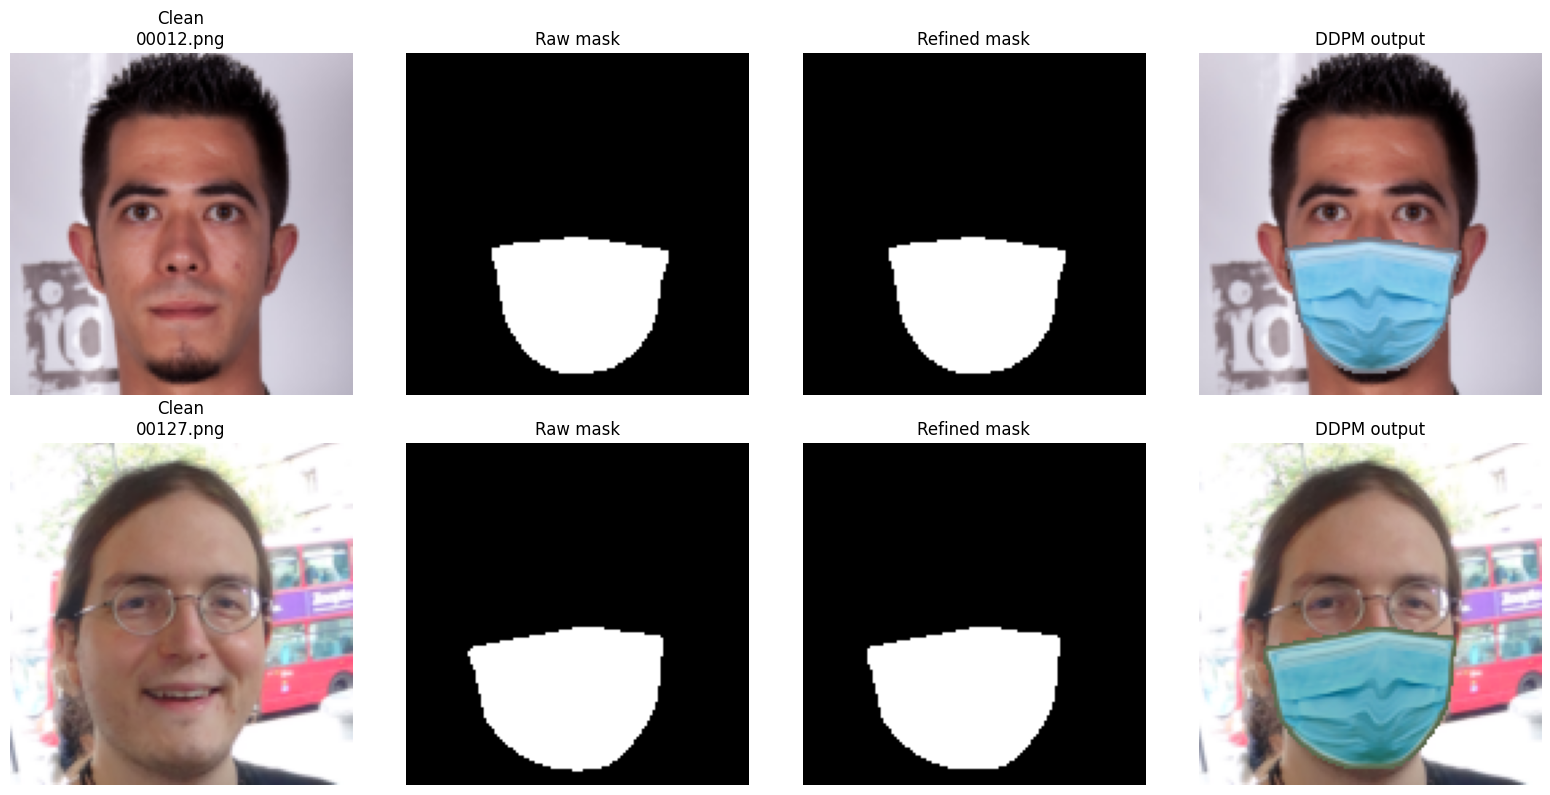

/home/onyxia/work/generation_mask/outputs/notebook_pipeline_00012_00127/predicted_masks/00012.png
/home/onyxia/work/generation_mask/outputs/notebook_pipeline_00012_00127/generated/00012.png
/home/onyxia/work/generation_mask/outputs/notebook_pipeline_00012_00127/predicted_masks/00127.png
/home/onyxia/work/generation_mask/outputs/notebook_pipeline_00012_00127/generated/00127.png


In [9]:
fig, axes = plt.subplots(len(results), 4, figsize=(16, 4 * len(results)))
if len(results) == 1:
    axes = [axes]

for row, result in zip(axes, results):
    row[0].imshow(result["clean"])
    row[0].set_title(f"Clean\n{result['name']}")
    row[0].axis("off")

    row[1].imshow(result["raw_mask"], cmap="gray")
    row[1].set_title("Raw mask")
    row[1].axis("off")

    row[2].imshow(result["pred_mask"], cmap="gray")
    row[2].set_title("Refined mask")
    row[2].axis("off")

    row[3].imshow(result["generated"])
    row[3].set_title("DDPM output")
    row[3].axis("off")

plt.tight_layout()
plt.show()

for result in results:
    print(result["pred_mask_path"])
    print(result["generated_path"])


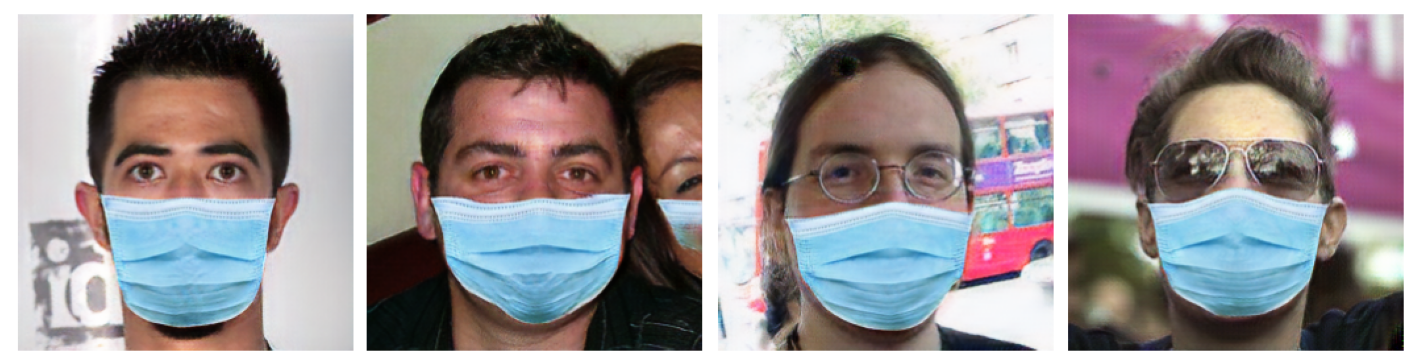

/home/onyxia/work/generation_mask/outputs/notebook_pipeline_00012_00127/test_image_without_middle_panel.png


In [12]:
composite_path = Path("/home/onyxia/work/test.png")
assert composite_path.exists(), f"Missing image: {composite_path}"

composite_image = Image.open(composite_path).convert("RGB")
panel_count = 5
panel_width = composite_image.width // panel_count
panels = []
for index in range(panel_count):
    left = index * panel_width
    right = composite_image.width if index == panel_count - 1 else (index + 1) * panel_width
    panels.append(composite_image.crop((left, 0, right, composite_image.height)))

# Remove the third panel and keep the remaining four in a single row.
kept_panels = [panel for index, panel in enumerate(panels) if index != 2]
combined_width = sum(panel.width for panel in kept_panels)
combined_height = max(panel.height for panel in kept_panels)
combined_image = Image.new("RGB", (combined_width, combined_height), color=(255, 255, 255))

x = 0
for panel in kept_panels:
    combined_image.paste(panel, (x, 0))
    x += panel.width

combined_path = output_dir / "test_image_without_middle_panel.png"
combined_image.save(combined_path)

plt.figure(figsize=(18, 5))
plt.imshow(combined_image)
plt.axis("off")
plt.show()

print(combined_path)
